# **E-Commerce Sales Analysis — Olist Dataset**

# **Data Cleaning**

## **Load and Clean Data**

In [153]:
import pandas as pd
import numpy as np


In [154]:
# Load datasets
orders = pd.read_csv('/Users/wafanur/Downloads/ecommerce-sales-analysis/data/olist_orders_dataset.csv')
items = pd.read_csv('/Users/wafanur/Downloads/ecommerce-sales-analysis/data/olist_order_items_dataset.csv')
customers = pd.read_csv('/Users/wafanur/Downloads/ecommerce-sales-analysis/data/olist_customers_dataset.csv')
products = pd.read_csv('/Users/wafanur/Downloads/ecommerce-sales-analysis/data/olist_products_dataset.csv')
payments = pd.read_csv('/Users/wafanur/Downloads/ecommerce-sales-analysis/data/olist_order_payments_dataset.csv')
reviews = pd.read_csv('/Users/wafanur/Downloads/ecommerce-sales-analysis/data/olist_order_reviews_dataset.csv')

In [155]:
# ── ORDERS ──────────────────────────────────────
print("=== ORDERS ===")
print(orders.shape)
print(orders.isnull().sum())

# Convert datetime columns
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# Keep only delivered orders
orders_clean = orders[orders['order_status'] == 'delivered'].copy()
print(f"\nDelivered orders: {len(orders_clean)}")

=== ORDERS ===
(99441, 8)
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Delivered orders: 96478


In [156]:
orders_clean

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15


In [157]:
# ── ITEMS ────────────────────────────────────────
print("\n=== ITEMS ===")
print(items.shape)
print(items.isnull().sum())
items_clean = items.dropna()


=== ITEMS ===
(112650, 7)
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


In [158]:
items_clean

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [159]:
# ── CUSTOMERS ────────────────────────────────────
print("\n=== CUSTOMERS ===")
print(customers.shape)
print(customers.isnull().sum())
customers_clean = customers.dropna()


=== CUSTOMERS ===
(99441, 5)
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


In [160]:
customers_clean

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


In [161]:
# ── PRODUCTS ─────────────────────────────────────
print("\n=== PRODUCTS ===")
print(products.shape)
# Fill missing category with 'unknown'
products['product_category_name'] = \
    products['product_category_name'].fillna('unknown')
products_clean = products.copy()


=== PRODUCTS ===
(32951, 9)


In [162]:
products_clean

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [163]:
# ── PAYMENTS ─────────────────────────────────────
print("\n=== PAYMENTS ===")
print(payments.shape)
print(payments.isnull().sum())
payments_clean = payments.dropna()


=== PAYMENTS ===
(103886, 5)
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64


In [164]:
payments_clean

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


In [165]:
# ── REVIEWS ──────────────────────────────────────
print("\n=== REVIEWS ===")
print(reviews.shape)
reviews_clean = reviews[['order_id', 'review_score']].dropna()


=== REVIEWS ===
(99224, 7)


In [166]:
reviews_clean

,order_id,review_score
0,73fc7af87114b39712e6da79b0a377eb,4
1,a548910a1c6147796b98fdf73dbeba33,5
2,f9e4b658b201a9f2ecdecbb34bed034b,5
3,658677c97b385a9be170737859d3511b,5
4,8e6bfb81e283fa7e4f11123a3fb894f1,5
...,...,...
99219,2a8c23fee101d4d5662fa670396eb8da,5
99220,22ec9f0669f784db00fa86d035cf8602,5
99221,55d4004744368f5571d1f590031933e4,5
99222,7725825d039fc1f0ceb7635e3f7d9206,4


## **Master Dataframe**

### **merge**

In [167]:
# ── MASTER MERGE ─────────────────────────────────
df = orders_clean.merge(items_clean, on='order_id', how='left')
df = df.merge(customers_clean, on='customer_id', how='left')
df = df.merge(products_clean[['product_id','product_category_name']], 
              on='product_id', how='left')
df = df.merge(payments_clean.groupby('order_id')['payment_value']
              .sum().reset_index(), on='order_id', how='left')
df = df.merge(reviews_clean, on='order_id', how='left')

print(f"\nMaster dataframe shape: {df.shape}")
print(df.head())


Master dataframe shape: (110840, 21)
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp   order_approved_at  \
0    delivered      2017-10-02 10:56:33 2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37 2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49 2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06 2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39 2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-

In [168]:
df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,shipping_limit_date,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name,payment_value,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,2017-10-06 11:07:15,29.99,8.72,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,utilidades_domesticas,38.71,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,2018-07-30 03:24:27,118.70,22.76,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,perfumaria,141.46,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,2018-08-13 08:55:23,159.90,19.22,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,automotivo,179.12,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,2017-11-23 19:45:59,45.00,27.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,pet_shop,72.20,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,...,2018-02-19 20:31:37,19.90,8.72,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,papelaria,28.62,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110835,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,1,f1d4ce8c6dd66c47bbaa8c6781c2a923,...,2018-02-12 13:10:37,174.90,20.10,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP,bebes,195.00,4.0
110836,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,1,b80910977a37536adeddd63663f916ad,...,2017-09-05 15:04:16,205.99,65.02,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA,eletrodomesticos_2,271.01,5.0
110837,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,1,d1c427060a0f73f6b889a5c7c61f2ac4,...,2018-01-12 21:36:21,179.99,40.59,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,informatica_acessorios,441.16,2.0
110838,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,2,d1c427060a0f73f6b889a5c7c61f2ac4,...,2018-01-12 21:36:21,179.99,40.59,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,informatica_acessorios,441.16,2.0


### **missing values**

In [169]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_count', ascending=False)

,missing_count,missing_pct
review_score,827,0.746121
order_approved_at,15,0.013533
order_delivered_customer_date,8,0.007218
payment_value,3,0.002707
order_delivered_carrier_date,2,0.001804
price,0,0.000000
product_category_name,0,0.000000
customer_state,0,0.000000
customer_city,0,0.000000
customer_zip_code_prefix,0,0.000000


#### **order_approved_at**

In [170]:
df.loc[
    df['order_approved_at'].isnull(),
    [
        'order_id',
        'order_status',
        'order_purchase_timestamp',
        'order_delivered_customer_date'
    ]
]

,order_id,order_status,order_purchase_timestamp,order_delivered_customer_date
5871,e04abd8149ef81b95221e88f6ed9ab6a,delivered,2017-02-18 14:40:00,2017-03-01 13:25:33
18447,8a9adc69528e1001fc68dd0aaebbb54a,delivered,2017-02-18 12:45:31,2017-03-02 10:05:06
21203,7013bcfc1c97fe719a7b5e05e61c12db,delivered,2017-02-18 13:29:47,2017-03-01 08:07:38
25226,5cf925b116421afa85ee25e99b4c34fb,delivered,2017-02-18 16:48:35,2017-03-09 07:28:47
25775,12a95a3c06dbaec84bcfb0e2da5d228a,delivered,2017-02-17 13:05:55,2017-03-02 11:09:19
29849,c1d4211b3dae76144deccd6c74144a88,delivered,2017-01-19 12:48:08,2017-01-30 18:16:01
42629,d69e5d356402adc8cf17e08b5033acfb,delivered,2017-02-19 01:28:47,2017-03-02 03:41:58
43802,d77031d6a3c8a52f019764e68f211c69,delivered,2017-02-18 11:04:19,2017-03-02 16:15:23
53871,7002a78c79c519ac54022d4f8a65e6e8,delivered,2017-01-19 22:26:59,2017-02-06 14:22:19
68670,2eecb0d85f281280f79fa00f9cec1a95,delivered,2017-02-17 17:21:55,2017-03-03 12:16:03


In [171]:
df = df.dropna(subset=['order_approved_at'])

#### **order_delivered_customer_date**

In [172]:
df.loc[
    df['order_delivered_customer_date'].isnull(),
    [
        'order_id',
        'order_status',
        'order_purchase_timestamp',
        'order_delivered_customer_date'
    ]
]

,order_id,order_status,order_purchase_timestamp,order_delivered_customer_date
3309,2d1e2d5bf4dc7227b3bfebb81328c15f,delivered,2017-11-28 17:44:07,NaT
22970,f5dd62b788049ad9fc0526e3ad11a097,delivered,2018-06-20 06:58:43,NaT
48808,2ebdfc4f15f23b91474edf87475f108e,delivered,2018-07-01 17:05:11,NaT
88214,e69f75a717d64fc5ecdfae42b2e8e086,delivered,2018-07-01 22:05:55,NaT
92203,0d3268bad9b086af767785e3f0fc0133,delivered,2018-07-01 21:14:02,NaT
103191,2d858f451373b04fb5c984a1cc2defaf,delivered,2017-05-25 23:22:43,NaT
108790,ab7c89dc1bf4a1ead9d6ec1ec8968a84,delivered,2018-06-08 12:09:39,NaT
109234,20edc82cf5400ce95e1afacc25798b31,delivered,2018-06-27 16:09:12,NaT


In [173]:
df = df.dropna(subset=['order_delivered_customer_date'])

#### **payment_value**

In [174]:
df.loc[
    df['payment_value'].isnull()
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,shipping_limit_date,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name,payment_value,review_score
34242,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,1,5a6b04657a4c5ee34285d1e4619a96b4,...,2016-09-19 23:11:33,44.99,2.83,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP,beleza_saude,NaN,1.0
34243,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,2,5a6b04657a4c5ee34285d1e4619a96b4,...,2016-09-19 23:11:33,44.99,2.83,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP,beleza_saude,NaN,1.0
34244,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,3,5a6b04657a4c5ee34285d1e4619a96b4,...,2016-09-19 23:11:33,44.99,2.83,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP,beleza_saude,NaN,1.0


In [175]:
df = df.dropna(subset=['payment_value'])

#### **order_delivered_carrier_date**

In [176]:
df.loc[
    df['order_delivered_carrier_date'].isnull()
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,shipping_limit_date,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name,payment_value,review_score
81525,2aa91108853cecb43c84a5dc5b277475,afeb16c7f46396c0ed54acb45ccaaa40,delivered,2017-09-29 08:52:58,2017-09-29 09:07:16,NaT,2017-11-20 19:44:47,2017-11-14,1,44c2baf621113fa7ac95fa06b4afbc68,...,2017-10-18 10:07:16,179.0,14.98,a2ac81ecc3704410ae240e74d4f0af40,13334,indaiatuba,SP,moveis_decoracao,193.98,5.0


In [177]:
df = df.dropna(subset=['order_delivered_carrier_date'])

#### **review_score**

In [178]:
df['review_score_cat'] = df['review_score'].fillna('No Review')

In [179]:
df.loc[
    df['review_score'].isnull()
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name,payment_value,review_score,review_score_cat
16,403b97836b0c04a622354cf531062e5f,738b086814c6fcc74b8cc583f8516ee3,delivered,2018-01-02 19:00:43,2018-01-02 19:09:04,2018-01-03 18:19:09,2018-01-20 01:38:59,2018-02-06,1,638bbb2a5e4f360b71f332ddfebfd672,...,1299.00,77.45,6e26bbeaa107ec34112c64e1ee31c0f5,21381,rio de janeiro,RJ,construcao_ferramentas_construcao,1376.45,NaN,No Review
346,4906eeadde5f70b308c20c4a8f20be02,4e7656e34357b93f14b40c6400ca3f6e,delivered,2017-12-08 04:45:26,2017-12-12 03:50:30,2017-12-12 17:43:21,2018-01-09 18:04:58,2018-01-03,1,ee406bf28024d97771c4b1e8b7e8e219,...,144.99,17.26,ea870f4fdfd85ac98ab775b76efe3143,23065,rio de janeiro,RJ,cool_stuff,162.25,NaN,No Review
420,b7a4a9ecb1cd3ef6a3e36a48e200e3be,c3d8fc500d86b1c961ee144395c13a57,delivered,2017-05-19 18:13:54,2017-05-20 11:35:41,2017-05-30 12:43:50,2017-06-08 07:53:42,2017-06-16,1,41171e11f920c47deb1809edda2bf09d,...,26.00,15.10,367f4686d7112d69feed92b02a1775ed,88501,lages,SC,moveis_decoracao,41.10,NaN,No Review
428,59b32faedc12322c672e95ec3716d614,5baa82a2c45fa3220cb57d9881db3211,delivered,2018-06-27 11:10:11,2018-06-28 02:15:51,2018-06-28 14:57:00,2018-07-06 16:37:36,2018-07-26,1,040f34fe061b6024771f641fe922e782,...,69.00,18.58,c56d066e503008b8d0bf4204857c588d,97110,santa maria,RS,relogios_presentes,87.58,NaN,No Review
449,c2215076050fa358934105b15c34cf3b,19e7a88b34ef70d108e660c6eb33e82a,delivered,2017-07-16 10:04:36,2017-07-16 10:15:15,2017-07-20 17:42:22,2017-07-26 20:32:17,2017-08-04,1,99a4788cb24856965c36a24e339b6058,...,89.90,12.13,f329e0e1d8897ffa466a836ed216a23b,3884,sao paulo,SP,cama_mesa_banho,102.03,NaN,No Review
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110082,906a6b0a96d89ee226e4977e99b80b9e,274a720e69d300bc7696c8570f8978fe,delivered,2017-08-28 15:14:21,2017-08-28 15:25:29,2017-08-31 15:25:01,2017-09-05 19:47:44,2017-09-18,1,8466762a9393a2b2b1de73f3cf6081a3,...,79.90,12.06,e2226f481eef03f2876d1a27f0f4b1b0,11030,santos,SP,moveis_sala,91.96,NaN,No Review
110342,5333db16fe357175d39c82840dd3269d,7e008e5ec21e044fe30c34ec4e9d0747,delivered,2018-03-10 18:18:20,2018-03-13 04:08:22,2018-03-13 17:58:52,2018-04-03 15:32:52,2018-03-29,1,4deb009c36a910076a023947a7929201,...,53.89,15.26,d06f106a141c540ca3b3cc0a3a8bba39,8141,sao paulo,SP,consoles_games,138.30,NaN,No Review
110343,5333db16fe357175d39c82840dd3269d,7e008e5ec21e044fe30c34ec4e9d0747,delivered,2018-03-10 18:18:20,2018-03-13 04:08:22,2018-03-13 17:58:52,2018-04-03 15:32:52,2018-03-29,2,4deb009c36a910076a023947a7929201,...,53.89,15.26,d06f106a141c540ca3b3cc0a3a8bba39,8141,sao paulo,SP,consoles_games,138.30,NaN,No Review
110494,2f2df159f26ddb73d55ee72372200d3e,86a7245fffe6a418ca1658a13ecc4531,delivered,2017-07-17 01:19:50,2017-07-17 01:30:09,2017-07-17 22:14:50,2017-07-26 09:44:00,2017-08-09,1,4052517cac9e78357d895976124f6972,...,150.00,16.81,1d532194f005426adcdf6d969640d56e,35240,conselheiro pena,MG,eletronicos,166.81,NaN,No Review


### **duplicates**

In [180]:
print(df.duplicated().sum())
df[df.duplicated()]

391


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name,payment_value,review_score,review_score_cat
445,ac7a92560a9e99f0a0ab4988102f491b,6abf781c5304890987047e9aa239caa8,delivered,2018-03-04 15:58:09,2018-03-04 16:10:35,2018-03-06 17:14:59,2018-03-22 23:44:33,2018-03-23,1,4ab7490d3e55de79cae5fc88e1657276,...,89.99,17.88,a176838867d89ed62981cdf02b7ca3e1,86040,londrina,PR,cama_mesa_banho,107.87,1.0,1.0
614,7845a2492ab1b4f2cf3d56c7b8da1446,386e96046ce0e77e5c9a9a4e818da93c,delivered,2018-01-18 12:35:45,2018-01-18 12:56:40,2018-01-18 23:42:44,2018-01-23 21:51:48,2018-02-09,1,16241e79b047426033194065d8b321b2,...,29.99,14.10,1175e95fb47ddff9de6b2b06188f7e0d,81560,curitiba,PR,moveis_decoracao,44.09,5.0,5.0
748,acbe07f22f29ad7e5a78f30008cc6ec7,b4afeb58ac51bc903c5362286c6a5cfe,delivered,2017-11-18 14:33:04,2017-11-18 19:06:16,2017-11-27 18:34:31,2017-11-29 17:58:43,2017-12-05,1,c0e452663c284f3f8e578f390dc3ab21,...,19.30,11.73,6457b2cb5462c1217e8e6d36b0ff39d2,5842,sao paulo,SP,bebidas,124.12,5.0,5.0
750,acbe07f22f29ad7e5a78f30008cc6ec7,b4afeb58ac51bc903c5362286c6a5cfe,delivered,2017-11-18 14:33:04,2017-11-18 19:06:16,2017-11-27 18:34:31,2017-11-29 17:58:43,2017-12-05,2,c0a0b5aa4507363e601eb90082c9c008,...,19.30,11.73,6457b2cb5462c1217e8e6d36b0ff39d2,5842,sao paulo,SP,bebidas,124.12,5.0,5.0
752,acbe07f22f29ad7e5a78f30008cc6ec7,b4afeb58ac51bc903c5362286c6a5cfe,delivered,2017-11-18 14:33:04,2017-11-18 19:06:16,2017-11-27 18:34:31,2017-11-29 17:58:43,2017-12-05,3,262855d4dd5b0d39f786a3c86c285c6a,...,19.30,11.73,6457b2cb5462c1217e8e6d36b0ff39d2,5842,sao paulo,SP,bebidas,124.12,5.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110152,66f943fd426ac8716ef6b6b97ace8bd8,592ef413ebc8f70a779b9282d2ea6020,delivered,2018-04-19 08:26:03,2018-04-19 08:35:19,2018-04-27 10:56:00,2018-05-04 19:51:06,2018-05-09,1,2350c74f45b4009cbdab3fa73396c222,...,52.00,22.94,d6df1c8cb71c59d9b52d828dc6d0f5b3,71926,brasilia,DF,eletrodomesticos,74.94,4.0,4.0
110368,76de574e14e58baded25a12dce8075c1,3dc99b2fcf41c0898cfc7f38c2fefe5e,delivered,2017-06-18 10:26:33,2017-06-18 10:42:57,2017-06-19 13:45:40,2017-06-22 16:04:05,2017-07-11,1,4a9389b1a1ad7d52963f24ce0391a08f,...,89.00,16.38,970e5961383615662043afa2d9c68802,30880,belo horizonte,MG,esporte_lazer,105.38,5.0,5.0
110396,2fcdb0c004a2a538d3dd724ea76916bd,cf826be53b1fe4a39bc33c7f5f827835,delivered,2017-11-22 11:39:00,2017-11-22 11:49:05,2017-11-23 22:58:51,2017-12-15 00:23:25,2017-12-18,1,8d139b1550c8cc91a3babc9cfe9fc147,...,55.00,35.71,d92462d83762d5e5c112bccc344119e6,65940,grajau,MA,telefonia,90.71,5.0,5.0
110436,dbfa3d8c05cc5d84083fc259a9feb5bc,92fc29e76e4da7c1b189ab092d4c3756,delivered,2018-01-04 22:57:14,2018-01-06 02:08:45,2018-01-13 00:51:54,2018-01-22 21:16:37,2018-02-01,1,4aaa2ddc43f64a2db232b71fc4639064,...,129.90,34.27,8901b2526349d372dd0bdf8d77af656d,79823,dourados,MS,eletronicos,164.17,5.0,5.0


In [181]:
df = df.drop_duplicates()

### **data types**

In [182]:
print(df.dtypes)

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
order_item_id                             int64
product_id                               object
seller_id                                object
shipping_limit_date                      object
price                                   float64
freight_value                           float64
customer_unique_id                       object
customer_zip_code_prefix                  int64
customer_city                            object
customer_state                           object
product_category_name                    object
payment_value                           float64
review_score                            

In [183]:
df['shipping_limit_date'].head()

0    2017-10-06 11:07:15
1    2018-07-30 03:24:27
2    2018-08-13 08:55:23
3    2017-11-23 19:45:59
4    2018-02-19 20:31:37
Name: shipping_limit_date, dtype: object

In [184]:
df['shipping_limit_date'] = pd.to_datetime(
    df['shipping_limit_date']
)

In [185]:
df['customer_zip_code_prefix'] = (
    df['customer_zip_code_prefix']
    .astype(str)
)

### **unique value**

In [186]:
for col in df.columns:
    print(col, df[col].nunique())

order_id 96454
customer_id 96454
order_status 1
order_purchase_timestamp 95932
order_approved_at 88265
order_delivered_carrier_date 80093
order_delivered_customer_date 95642
order_estimated_delivery_date 444
order_item_id 21
product_id 32210
seller_id 2970
shipping_limit_date 91320
price 5859
freight_value 6924
customer_unique_id 93335
customer_zip_code_prefix 14889
customer_city 4085
customer_state 27
product_category_name 74
payment_value 27456
review_score 5
review_score_cat 6


### **translate**

In [187]:
df['product_category_name']

0          utilidades_domesticas
1                     perfumaria
2                     automotivo
3                       pet_shop
4                      papelaria
                   ...          
110835                     bebes
110836        eletrodomesticos_2
110837    informatica_acessorios
110838    informatica_acessorios
110839              beleza_saude
Name: product_category_name, Length: 110422, dtype: object

In [188]:
translation = pd.read_csv('/Users/wafanur/Downloads/ecommerce-sales-analysis/data/product_category_name_translation.csv')

In [189]:
df['product_category_name'] = (
    df['product_category_name']
    .str.strip()
)

translation['product_category_name'] = (
    translation['product_category_name']
    .str.strip()
)

In [190]:
print(df['product_category_name'].nunique())

74


In [191]:
print(translation['product_category_name'].nunique())

71


In [192]:
missing_categories = (
    set(df['product_category_name'].dropna().unique())
    - set(translation['product_category_name'].unique())
)

print(missing_categories)
print("not found categories:", len(missing_categories))

{'pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos', 'unknown'}
not found categories: 3


In [193]:
extra_mapping = {
    'pc_gamer': 'gaming_pc',
    'portateis_cozinha_e_preparadores_de_alimentos':
        'portable_kitchen_and_food_preparation_appliances',
    'unknown': 'unknown'
}

In [194]:
mapping = dict(zip(
    translation['product_category_name'],
    translation['product_category_name_english']
))

mapping.update(extra_mapping)

In [195]:
df['product_category_name_english'] = (
    df['product_category_name']
    .map(mapping)
)

In [196]:
df['product_category_name'].isna().sum()

0

In [197]:
df = df.drop(columns=['product_category_name'])

df = df.rename(columns={
    'product_category_name_english': 'product_category_name'
})

### **save**

In [198]:
# Save cleaned master
df.to_csv('/Users/wafanur/Downloads/ecommerce-sales-analysis/data/master_clean.csv', index=False)
print("\nSaved to master_clean.csv")


Saved to master_clean.csv


# **Exploratory Data Analysis**

In [199]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [200]:
df = pd.read_csv('/Users/wafanur/Downloads/ecommerce-sales-analysis/data/master_clean.csv', 
                 parse_dates=['order_purchase_timestamp'])

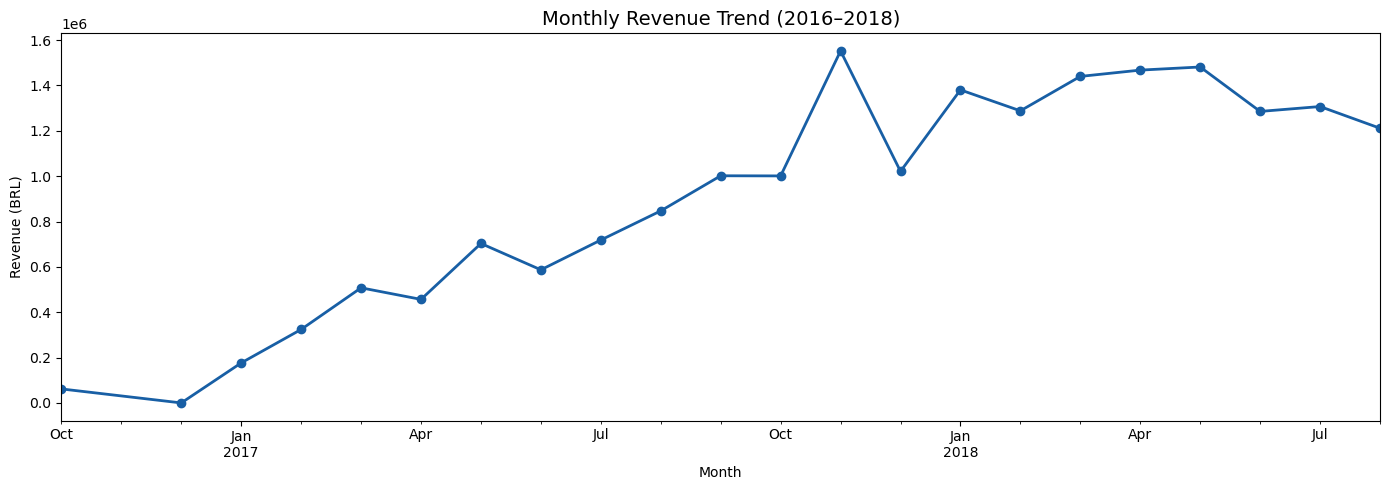

In [201]:
# ── 1. REVENUE TREND ─────────────────────────────
df['year_month'] = df['order_purchase_timestamp'].dt.to_period('M')
monthly_revenue = df.groupby('year_month')['payment_value'].sum()

plt.figure(figsize=(14, 5))
monthly_revenue.plot(kind='line', marker='o', color='#185FA5', linewidth=2)
plt.title('Monthly Revenue Trend (2016–2018)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Revenue (BRL)')
plt.tight_layout()
plt.savefig('/Users/wafanur/Downloads/ecommerce-sales-analysis/assets/01_revenue_trend.png', dpi=150)
plt.show()

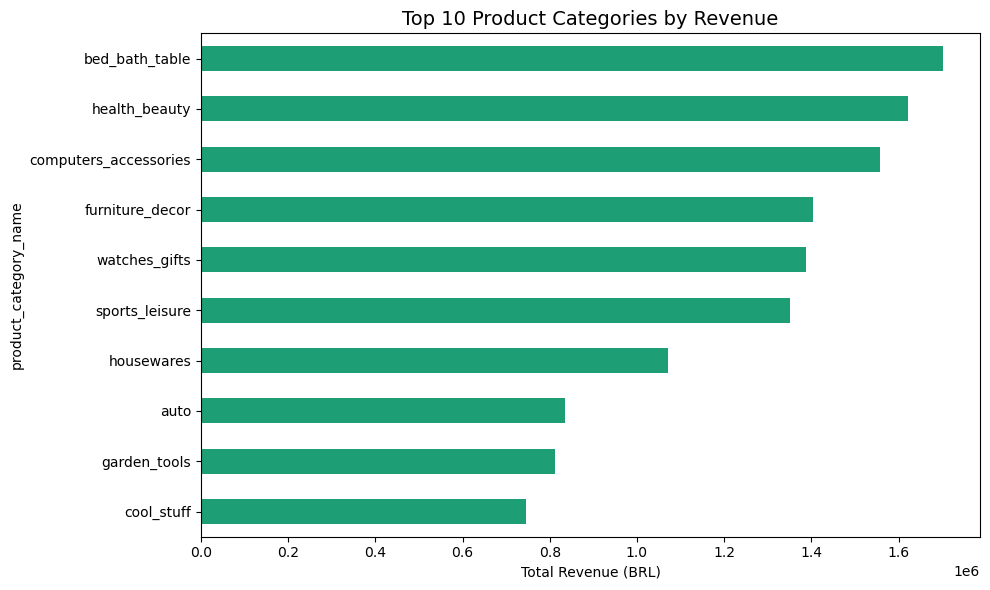

In [202]:
# ── 2. TOP PRODUCT CATEGORIES ────────────────────
top_categories = (df.groupby('product_category_name')['payment_value']
                  .sum()
                  .sort_values(ascending=False)
                  .head(10))

plt.figure(figsize=(10, 6))
top_categories.sort_values().plot(kind='barh', color='#1D9E75')
plt.title('Top 10 Product Categories by Revenue', fontsize=14)
plt.xlabel('Total Revenue (BRL)')
plt.tight_layout()
plt.savefig('/Users/wafanur/Downloads/ecommerce-sales-analysis/assets/02_top_categories.png', dpi=150)
plt.show()

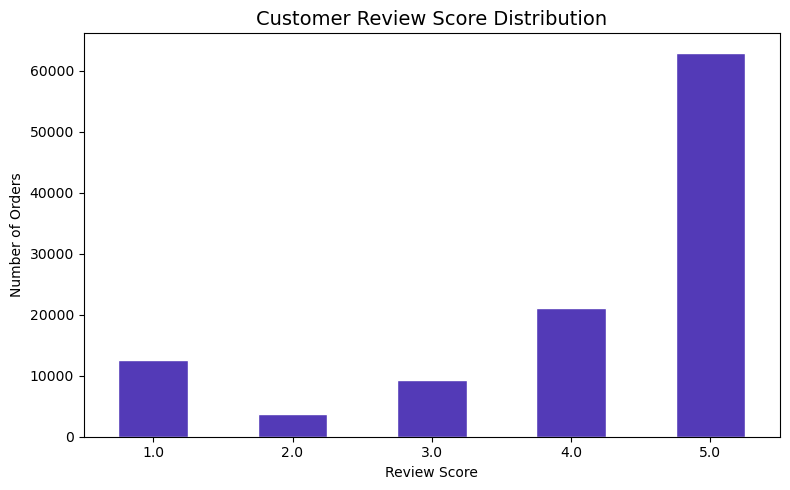

In [203]:
# ── 3. REVIEW SCORE DISTRIBUTION ─────────────────
plt.figure(figsize=(8, 5))
df['review_score'].value_counts().sort_index().plot(
    kind='bar', color='#533AB7', edgecolor='white')
plt.title('Customer Review Score Distribution', fontsize=14)
plt.xlabel('Review Score')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('/Users/wafanur/Downloads/ecommerce-sales-analysis/assets/03_review_scores.png', dpi=150)
plt.show()

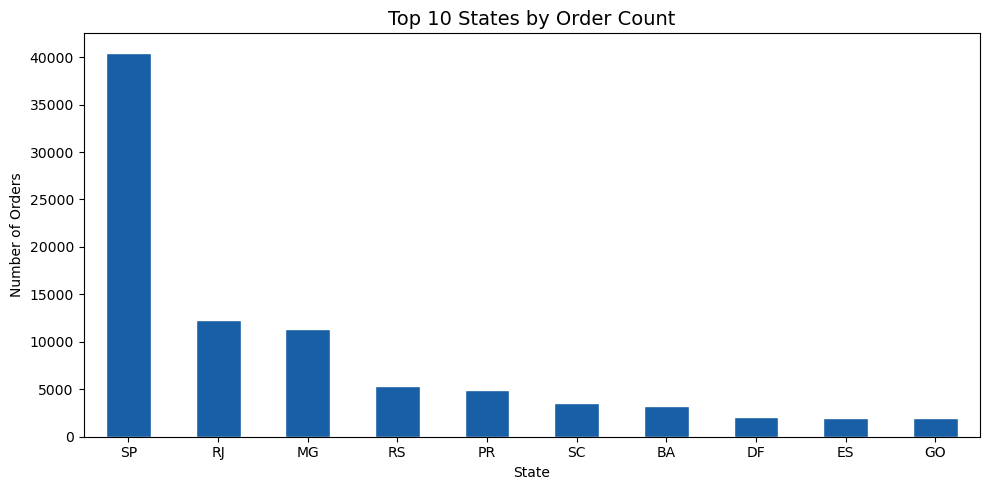

In [204]:
# ── 4. TOP STATES BY ORDER COUNT ─────────────────
top_states = (df.groupby('customer_state')['order_id']
              .nunique()
              .sort_values(ascending=False)
              .head(10))

plt.figure(figsize=(10, 5))
top_states.plot(kind='bar', color='#185FA5', edgecolor='white')
plt.title('Top 10 States by Order Count', fontsize=14)
plt.xlabel('State')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('/Users/wafanur/Downloads/ecommerce-sales-analysis/assets/04_top_states.png', dpi=150)
plt.show()

On-time delivery rate: 92.6%
Average delivery days: 12.0


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


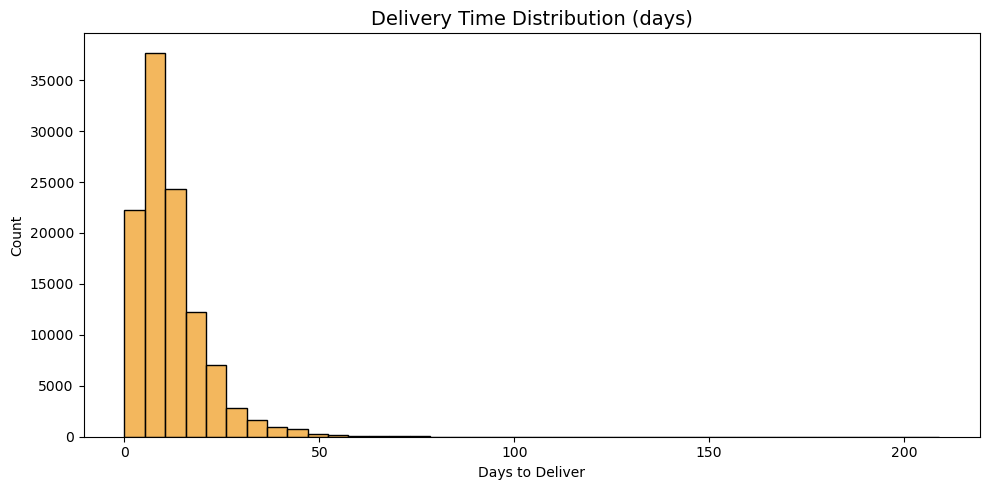

In [205]:
# ── 5. DELIVERY TIME ANALYSIS ────────────────────
df['delivery_days'] = (
    pd.to_datetime(df['order_delivered_customer_date']) - 
    pd.to_datetime(df['order_purchase_timestamp'])
).dt.days

df['estimated_days'] = (
    pd.to_datetime(df['order_estimated_delivery_date']) - 
    pd.to_datetime(df['order_purchase_timestamp'])
).dt.days

df['on_time'] = df['delivery_days'] <= df['estimated_days']

print(f"On-time delivery rate: {df['on_time'].mean()*100:.1f}%")
print(f"Average delivery days: {df['delivery_days'].mean():.1f}")

plt.figure(figsize=(10, 5))
sns.histplot(df['delivery_days'].dropna(), bins=40, color='#EF9F27')
plt.title('Delivery Time Distribution (days)', fontsize=14)
plt.xlabel('Days to Deliver')
plt.tight_layout()
plt.savefig('/Users/wafanur/Downloads/ecommerce-sales-analysis/assets/05_delivery_time.png', dpi=150)
plt.show()

In [206]:
# ── SUMMARY STATS ─────────────────────────────────
print("\n=== SUMMARY ===")
print(f"Total orders: {df['order_id'].nunique():,}")
print(f"Total revenue: BRL {df['payment_value'].sum():,.0f}")
print(f"Avg order value: BRL {df['payment_value'].mean():.2f}")
print(f"Avg review score: {df['review_score'].mean():.2f}")


=== SUMMARY ===
Total orders: 96,454
Total revenue: BRL 19,818,156
Avg order value: BRL 179.48
Avg review score: 4.08


# **Visualization**

In [207]:
import pandas as pd
import numpy as np

In [208]:
df = pd.read_csv('/Users/wafanur/Downloads/ecommerce-sales-analysis/data/master_clean.csv',
                 parse_dates=['order_purchase_timestamp',
                              'order_delivered_customer_date',
                              'order_estimated_delivery_date'])

In [209]:
# ── 1. MONTHLY REVENUE ───────────────────────────
monthly = (df.groupby(df['order_purchase_timestamp'].dt.to_period('M'))
             .agg(revenue=('payment_value','sum'),
                  orders=('order_id','nunique'))
             .reset_index())
monthly['month'] = monthly['order_purchase_timestamp'].astype(str)
monthly.drop(columns='order_purchase_timestamp', inplace=True)
monthly.to_csv('/Users/wafanur/Downloads/ecommerce-sales-analysis/tableau/tableau_monthly_revenue.csv', index=False)
print("✓ tableau_monthly_revenue.csv")

✓ tableau_monthly_revenue.csv


In [210]:
# ── 2. CATEGORY REVENUE ──────────────────────────
category = (df.groupby('product_category_name')
              .agg(revenue=('payment_value','sum'),
                   orders=('order_id','nunique'))
              .reset_index()
              .sort_values('revenue', ascending=False))
category.to_csv('/Users/wafanur/Downloads/ecommerce-sales-analysis/tableau/tableau_category_revenue.csv', index=False)
print("✓ tableau_category_revenue.csv")

✓ tableau_category_revenue.csv


In [211]:
# ── 3. REVIEW SCORES ─────────────────────────────
reviews = (df['review_score'].value_counts()
             .reset_index()
             .rename(columns={'index':'score','review_score':'count'}))
reviews.columns = ['score','count']
reviews = reviews.sort_values('score')
reviews.to_csv('/Users/wafanur/Downloads/ecommerce-sales-analysis/tableau/tableau_reviews.csv', index=False)
print("✓ tableau_reviews.csv")

✓ tableau_reviews.csv


In [212]:
# ── 4. STATE ORDERS ──────────────────────────────
states = (df.groupby('customer_state')
            .agg(orders=('order_id','nunique'),
                 revenue=('payment_value','sum'))
            .reset_index()
            .sort_values('orders', ascending=False))
states.to_csv('/Users/wafanur/Downloads/ecommerce-sales-analysis/tableau/tableau_states.csv', index=False)
print("✓ tableau_states.csv")

✓ tableau_states.csv


In [213]:
# ── 5. DELIVERY PERFORMANCE ──────────────────────
df['delivery_days'] = (
    df['order_delivered_customer_date'] -
    df['order_purchase_timestamp']
).dt.days

df['estimated_days'] = (
    df['order_estimated_delivery_date'] -
    df['order_purchase_timestamp']
).dt.days

df['on_time'] = df['delivery_days'] <= df['estimated_days']

delivery = df[['order_id','delivery_days',
               'estimated_days','on_time',
               'customer_state']].dropna()
delivery.to_csv('/Users/wafanur/Downloads/ecommerce-sales-analysis/tableau/tableau_delivery.csv', index=False)
print("✓ tableau_delivery.csv")

✓ tableau_delivery.csv


In [214]:
# ── 6. MASTER SUMMARY (untuk overview sheet) ─────
summary = df[['order_id',
              'order_purchase_timestamp',
              'customer_state',
              'product_category_name',
              'payment_value',
              'review_score',
              'delivery_days',
              'on_time']].dropna(subset=['payment_value'])
summary['year']  = summary['order_purchase_timestamp'].dt.year
summary['month'] = summary['order_purchase_timestamp'].dt.month
summary['month_name'] = summary['order_purchase_timestamp'].dt.strftime('%b')
summary.to_csv('/Users/wafanur/Downloads/ecommerce-sales-analysis/tableau/tableau_master.csv', index=False)
print("✓ tableau_master.csv")

print("\n=== Export complete ===")
print(f"Rows in master: {len(summary):,}")
print(f"Revenue total:  BRL {summary['payment_value'].sum():,.0f}")
print(f"On-time rate:   {delivery['on_time'].mean()*100:.1f}%")
print(f"Avg delivery:   {delivery['delivery_days'].mean():.1f} days")

✓ tableau_master.csv

=== Export complete ===
Rows in master: 110,422
Revenue total:  BRL 19,818,156
On-time rate:   92.6%
Avg delivery:   12.0 days


In [215]:
import pandas as pd

tm = pd.read_csv('/Users/wafanur/Downloads/ecommerce-sales-analysis/tableau/tableau_master.csv')

print("Shape:", tm.shape)
print("columns:", len(tm.columns))
print(tm.columns.tolist())

Shape: (110422, 11)
columns: 11
['order_id', 'order_purchase_timestamp', 'customer_state', 'product_category_name', 'payment_value', 'review_score', 'delivery_days', 'on_time', 'year', 'month', 'month_name']


In [216]:
for col in tm.columns:
    if "\n" in col:
        print("error column:", repr(col))

In [217]:
with open('/Users/wafanur/Downloads/ecommerce-sales-analysis/tableau/tableau_master.csv', "r", encoding="utf-8") as f:
    print(repr(f.readline()))

'order_id,order_purchase_timestamp,customer_state,product_category_name,payment_value,review_score,delivery_days,on_time,year,month,month_name\n'


In [218]:
with open('/Users/wafanur/Downloads/ecommerce-sales-analysis/tableau/tableau_master.csv', "r", encoding="utf-8") as f:
    for i in range(5):
        row = f.readline()
        print(f"Rows {i+1}: {row.count(',')+1} columns")

Rows 1: 11 columns
Rows 2: 11 columns
Rows 3: 11 columns
Rows 4: 11 columns
Rows 5: 11 columns


In [219]:
print(tm.dtypes)

order_id                     object
order_purchase_timestamp     object
customer_state               object
product_category_name        object
payment_value               float64
review_score                float64
delivery_days                 int64
on_time                        bool
year                          int64
month                         int64
month_name                   object
dtype: object


In [220]:
summary = df[['order_id',
              'order_purchase_timestamp',
              'customer_state',
              'product_category_name',
              'payment_value',
              'review_score',
              'delivery_days',
              'on_time']].dropna(subset=['payment_value'])
summary['year']  = summary['order_purchase_timestamp'].dt.year
summary['month'] = summary['order_purchase_timestamp'].dt.month
summary['month_name'] = summary['order_purchase_timestamp'].dt.strftime('%b')
summary.to_csv('/Users/wafanur/Downloads/ecommerce-sales-analysis/tableau/tableau_master.csv', index=False)
print("✓ tableau_master.csv")

print("\n=== Export complete ===")
print(f"Rows in master: {len(summary):,}")
print(f"Revenue total:  BRL {summary['payment_value'].sum():,.0f}")
print(f"On-time rate:   {delivery['on_time'].mean()*100:.1f}%")
print(f"Avg delivery:   {delivery['delivery_days'].mean():.1f} days")

✓ tableau_master.csv

=== Export complete ===
Rows in master: 110,422
Revenue total:  BRL 19,818,156
On-time rate:   92.6%
Avg delivery:   12.0 days
